In [1]:
# @title Libs


from matplotlib import rc
from matplotlib.widgets import Slider, Button
rc('animation', html='jshtml')
from matplotlib import cm
import matplotlib.colors as colors
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib
from numba import njit
from tqdm import tqdm
from random import random
from scipy import stats
from scipy import interpolate
from scipy import optimize
from scipy import integrate
from scipy.special import erf
import time
import pandas as pd
from numpy import array
#config.disable_caching = True
font = {'weight' : 'normal',
        'size'   : 15}
matplotlib.rc('font', **font)  # pass in the font dict as kwargs
#!jt -r
#!jt -l
#!jt -t <new_thema> -T -N -kl
pi = np.arccos(-1)
print(pi)


3.141592653589793


In [2]:
# @title ABCD matrices

def prop(d):
  return np.array([[1,d],[0,1]])


def lens(f):
  return np.array([[1,0],[-1/f,1]])

def refr(n0,n,r):
  if (abs(r) < 1e5):
    return np.array([[1,0],[(n0-n)/(r*n),n0/n]])
  else: return np.array([[1,0],[0,n0/n]])

def curved_mirror(n,r,t):
  return refr(n,1,1e9) @ prop(t) @ refr(1,n,-r)

def curved_mirror2(n,r,t):
  return refr(n,1,r) @ prop(t) @ refr(1,n,1e9)



In [12]:
# @title Simulation parameters

#all distances in mm

# beam initial parameters
l = 1560 * 1e-6
w0 = 0.5*10.1 * 1e-3
q0 = 1j * pi*w0*w0/l

#glass refr index
n = 1.5
#mirror thickness
th = 6

#radius of curvature of mirrors
R = 100

#cavity length
L = 50

g = 1 - L/R

#lens focal lenghts
f1 = 7.5
f2 = -R/2

#distances
# d1 = 4.784
d1 = 7.792
d2 = 176
d_win = d2-18
th_win = 3
dend = 400

d_cav_waist = d2 + L/2

# w0cav = np.sqrt(0.5*(l*L/(pi*2*g*(1-g)))*np.sqrt(g**2 * (1 - g**2)))
# q0cav = 1j * pi*w0cav*w0cav/l

q0cavrec = ((g-1) - (g**2 - 1)**(1/2) )/L
print(1/np.real(q0cavrec))
q0cav = 1/q0cavrec

print()

-100.0



In [13]:
# @title Propagation functions for thin lenses

def w(z,d1,d2):
  n1 = 1

  if (z <= d1):
    T = prop(z)

  elif ((z > d1) and (z <= d_win - th_win)):
    #T = prop(d1) @ lens(f1) @ prop(z-d1)
    T = prop(z-d1) @ lens(f1) @ prop(d1)

  elif ((z > d_win - th_win) and (z <= d_win)):
    #T = prop(d1) @ lens(f1) @ prop(z-d1)
    T = prop(z - (d_win - th_win)) @ refr(1,n,1e9) @ prop(d_win - th_win - d1) @ lens(f1) @ prop(d1)
    n1=n

  elif ((z > d_win) and (z <= d2 - th)):
    #T = prop(d1) @ lens(f1) @ prop(z-d1)
    T = prop(z - d_win) @ refr(n,1,1e9) @ prop(th_win) @ refr(1,n,1e9) @ prop(d_win - th_win - d1) @ lens(f1) @ prop(d1)

  elif ((z > d2) and (z <= d2 + L)):
    #T = prop(d1) @ lens(f1) @ prop(d2 - d1) @ lens(f2) @ prop(z - d2)
    T = prop(z - d2) @ curved_mirror2(n,R,th) @ prop(d2 - th - d_win) @ refr(n,1,1e9) @ prop(th_win) @ refr(1,n,1e9) @ prop(d_win - th_win - d1) @ lens(f1) @ prop(d1)

  elif ((z > d2 + L + th) and (z <= dend)):
    #T = prop(d1) @ lens(f1) @ prop(d2 - d1) @ lens(f2) @ prop(z - d2)
    T =  prop(z-d2-L-th) @ curved_mirror(n,R,th) @ prop(L) @ curved_mirror2(n,R,th) @ prop(d2 - th - d_win) @ refr(n,1,1e9) @ prop(th_win) @ refr(1,n,1e9) @ prop(d_win - th_win - d1) @ lens(f1) @ prop(d1)

  # elif ((z > d3) and (z <= dend)):
  #   #T = prop(d1) @ lens(f1) @ prop(d2 - d1) @ lens(f2) @ prop(d3 - d2) @ lens(f3) @ prop(z - d3)
  #   T = prop(z - d3) @ lens(f3) @ prop(d3 - d2) @ lens(f2) @ prop(d2 - d1) @ lens(f1) @ prop(d1)
  else: return

  A = T[0,0]
  B = T[0,1]
  C = T[1,0]
  D = T[1,1]
  #q = (A*q0+B)/(C*q0+D)
  q_rec = (C + (D/q0))/(A + (B/q0))

  #return np.sqrt(l*np.abs(q)**2/(pi*np.imag(q)))
  return ((-1)*l/(pi*n1*np.imag(q_rec)))**(1/2)





def wback(z1,d1,d2):
  dwaist = d2 + L/2
  # z = dwaist - z1
  z = z1 - d2

  if (z <= -th):
    T = prop(z + th) @ curved_mirror(n,-R,-th)

  elif ((z <= L) and (z > 0)):
    T = prop(z)

  elif (z > L + th) :
    # T = prop(L) @ lens(f2) @ prop(z-L)
    T = prop(z - (L + th)) @ curved_mirror(n,R,th) @ prop(L)

  else: return 

  A = T[0,0]
  B = T[0,1]
  C = T[1,0]
  D = T[1,1]
  #q = (A*q0+B)/(C*q0+D)
  q_rec = (C + q0cavrec*D)/(A + q0cavrec*B)

  #return np.sqrt(l*np.abs(q)**2/(pi*np.imag(q)))
  return ((-1)*l/(pi*np.imag(q_rec)))**(1/2)

def wback0(z1,d1,d2):
  dwaist = d2 + L/2
  # z = dwaist - z1
  z = d2 + L - z1


  T = prop(z)

  A = T[0,0]
  B = T[0,1]
  C = T[1,0]
  D = T[1,1]
  #q = (A*q0+B)/(C*q0+D)
  q_rec = (C + q0cavrec*D)/(A + q0cavrec*B)

  #return np.sqrt(l*np.abs(q)**2/(pi*np.imag(q)))
  return ((-1)*l/(pi*np.imag(q_rec)))**(1/2)



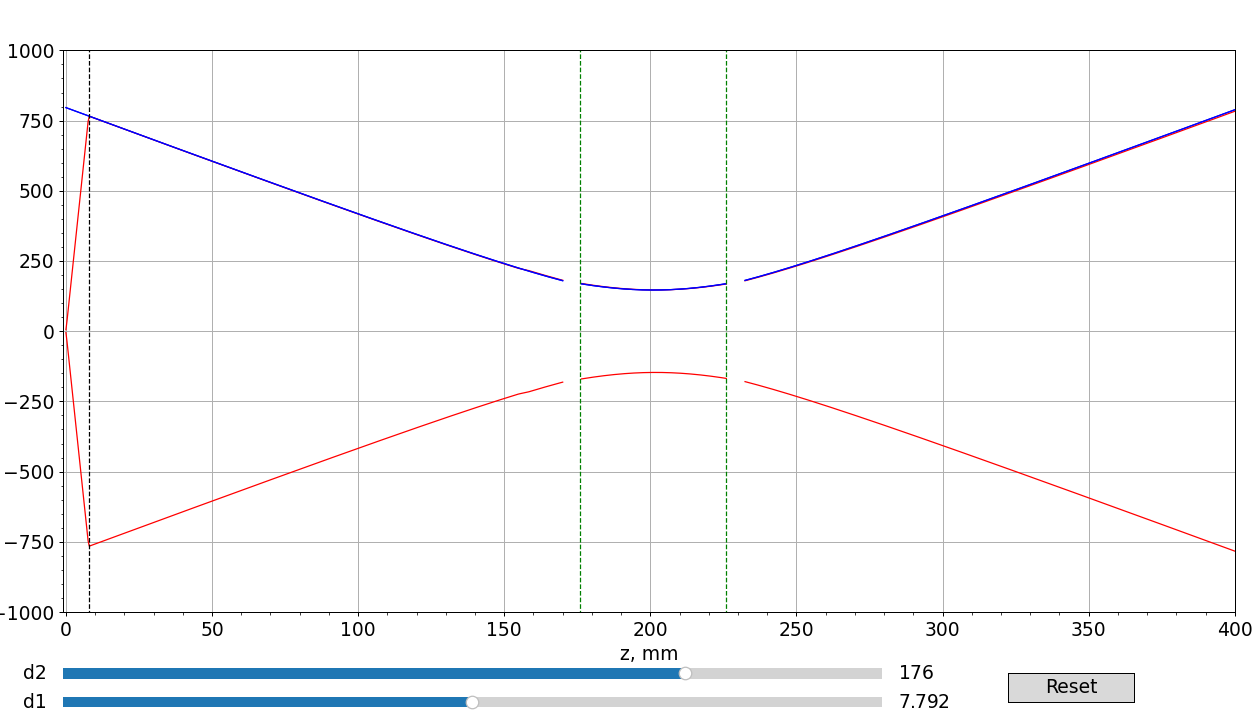

In [14]:
# @title Plot

plt.close('all')
%matplotlib ipympl
zarr = np.linspace(0,dend,1001)
warr = np.linspace(-3,3,2)
wv = np.vectorize(w)
wbackv = np.vectorize(wback)
wbackv0 = np.vectorize(wback0)

# Define initial parameters
init_d1 = d1
init_d2 = d2

# Create the figure and the line that we will manipulate
fig, ax = plt.subplots(figsize=(14, 8),dpi = 90)
line1, = ax.plot(zarr, 1e3*wv(zarr,init_d1,init_d2), lw=1,color='red')
line2, = ax.plot(zarr, 1e3*(-1)*wv(zarr,init_d1,init_d2), lw=1,color='red')
line3, = ax.plot(zarr, 1e3*wbackv(zarr,init_d1,init_d2), lw=1,color='blue')
line4, = ax.plot(zarr, 1e3*(-1)*-wbackv(zarr,init_d1,init_d2), lw=1,color='blue')
line5 ,= ax.plot(init_d1*np.ones(2), 1e3*warr, lw=1,color='black',ls='--')
line6 ,= ax.plot(init_d2*np.ones(2), 1e3*warr, lw=1,color='green',ls='--')
line7 ,= ax.plot((init_d2 + L)*np.ones(2), 1e3*warr, lw=1,color='green',ls='--')
# line8 ,= ax.plot(zarr, 1e3*wbackv0(zarr,init_d1,init_d2), lw=1,color='orange')


#line2,= plt.plot(zarr, zarr*0, lw=1,color='black')

ax.set_xlabel('z, mm')
ax.set_ylabel('w, um')
ax.set_ylim(-1000,1000)
ax.set_xlim(-1,dend)


# adjust the main plot to make room for the sliders
plt.subplots_adjust(left=0.05, right=0.98, bottom=0.15,top=0.93)

# Make a horizontal slider to control the frequency.
axd1 = plt.axes([0.05, 0.01, 0.65, 0.03])
d1_slider = Slider(
    ax=axd1,
    label='d1',
    valmin=d1*0.9,
    valmax=d1*1.1,
    valinit=init_d1,
)

# Make a vertically oriented slider to control the amplitude
axdr = plt.axes([0.05, 0.05, 0.65, 0.03])#([0.1, 0.25, 0.0225, 0.63])
d2_slider = Slider(
    ax=axdr,
    label="d2",
    valmin=100,
    valmax=200,
    valinit=init_d2,
    #orientation="vertical"
)


# The function to be called anytime a slider's value changes
def update(val):
    line1.set_ydata(1e3*wv(zarr, d1_slider.val, d2_slider.val))
    line2.set_ydata(1e3*(-1)*wv(zarr, d1_slider.val, d2_slider.val))
    line3.set_ydata(1e3*wbackv(zarr, d1_slider.val, d2_slider.val))
    line4.set_ydata(1e3*(-1)*wbackv(zarr, d1_slider.val, d2_slider.val))
    line5.set_xdata(d1_slider.val*np.ones(2))
    line6.set_xdata((d2_slider.val)*np.ones(2))
    line7.set_xdata((L + d2_slider.val)*np.ones(2))
    # line8.set_ydata(1e3*wbackv0(zarr, d1_slider.val, d2_slider.val))


    fig.canvas.draw_idle()


# register the update function with each slider
d1_slider.on_changed(update)
d2_slider.on_changed(update)

# Create a `matplotlib.widgets.Button` to reset the sliders to initial values.
resetax = plt.axes([0.8, 0.025, 0.1, 0.04])
button = Button(resetax, 'Reset', hovercolor='0.975')


def reset(event):
    d1_slider.reset()
    d2_slider.reset()

button.on_clicked(reset)
ax.minorticks_on()
#ax[1].minorticks_on()

ax.grid(True)
#ax[1].grid(True)

plt.show()

In [6]:
print(f'Cavity waist diameter = {2e3*wback(d2+L/2,d1,d2):.1f}')

Cavity waist diameter = 293.3


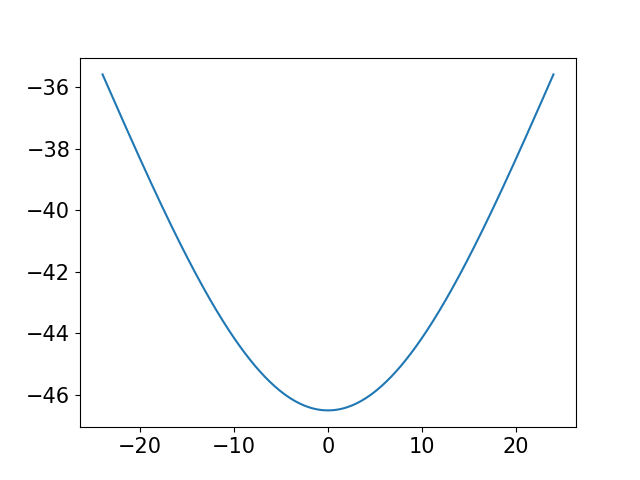

In [7]:
plt.close()
def U(x):
    z = d2+L/2 + x
    return -wback(z,d1,d2)**(-2)

Uv = np.vectorize(U)
xarr = np.linspace(-24,24,1001)
plt.plot(xarr,Uv(xarr))
plt.show()

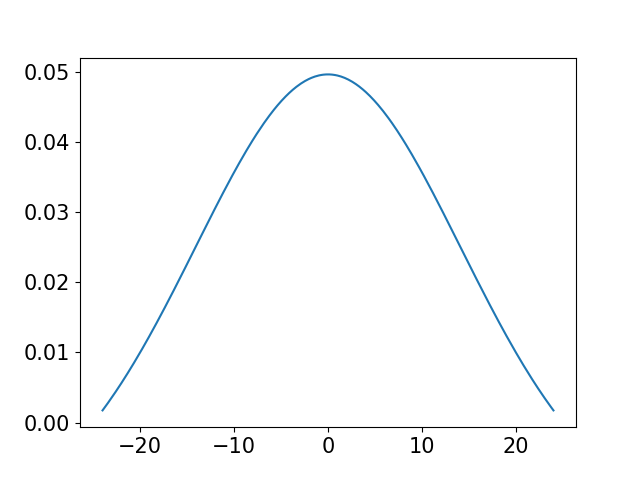

In [8]:
def der2(f,h=1e-4):
    def ddf(x):
        return (f(x+2*h) - 2*f(x) + f(x-2*h))/(4*h*h)
    return ddf

plt.close()


Uv = np.vectorize(U)
der2U = der2(Uv)
xarr = np.linspace(-24,24,1001)
plt.plot(xarr,der2U(xarr))
plt.show()